# Oregon Surf Analysis
+ Xander Hawkins  
+ Spring 2026

## Project Overview
This project seeks to understand the regional differences in surfing conditions in Oregon.  

Using historical data from the National Data Buoy Center's offshore buoy stations, various conditions such as
Ocean temperature, swell, wave height and period and direction are used to determine whether the South,
Central, or North Coast of Oregon have experienced the best, most consistent surfing conditions. Conventional
wisdom in Oregon claims that the Central Coast is best, and I seek to rigorously test that hypothesis against the data.

Some NDBC Buoys (including those selected for this project) have additional spectral data available on wave behavior.
With the use of Fourier Analysis, this allows us to differentiate between waves caused by swell and those by wind, 
which has tremendous implications for surfing. However, the spectral data substantially increases the volume of data
for cleaning, and the analyis required is non-trivial. Therefore, it remains a stretch goal for this project.

While I initially sought to determine which beach is best, the buoy data is not granular enough. There are a few
interesting approaches to approximating historical conditions at the level of individual beaches, but for now a
regional analysis was more practical given time constraints.

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ndbc_api import NdbcApi
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

## Configuration
Here, the data parameters can be easily modified to adjust the scope of the analysis. A few key marks:
+ Regional coverage: add or remove buoys. Buoy IDs and locations can be found online.
+ Temporal coverage: reduce or increase start & end date. Note that many buoys have limited historical data.
+ Sentinel values: adjust these if NDBC changes their structure in the future.

In [33]:
# Configuration 

# NDBC buoy stations, grouped by Oregon coast region
BUOYS = {
    'north':   '46089',  # Tillamook, 85 NM WNW of Tillamook
    'central': '46050',  # Stonewall Bank, 20 NM W of Newport
    'south':   '46015',  # Port Orford, 15 NM W of Port Orford
}

# Analysis time window: inclusive on both ends. NDBC API expects 'yyyy-mm-dd'
START_DATE = '2015-01-01'
END_DATE = '2025-12-31'

# NDBC sentinel values for missing data across their various fields
NDBC_MISSING = [99.0, 999.0, 9999.0]

# Output paths
DATA_DIR = 'data'
CACHE_DIR = 'data/raw'

# Buoy locations (decimal degrees, from NDBC station pages)
# Source: https://www.ndbc.noaa.gov/station_page.php?station=<station_id>
BUOY_LOCATIONS = {
    BUOYS['north']: {'lat': 45.928, 'lon': -125.815},  # Tillamook
    BUOYS['central']: {'lat': 44.679, 'lon': -124.535},  # Newport
    BUOYS['south']: {'lat': 42.754, 'lon': -124.839},  # Port Orford
}

## Data Import
### Standard Meteorological Data
Import the standard data from each of the specified buoys for the given time period.

As of April 2026, the NDBC API function for pulling buoy data has a bug. Therefore, we define a custom function for
pulling one buoy-year of data using the buoy station number and the year. Then, we loop through our regions and years
and concatenate the buoy-years of data into a single dataframe. 

If any years are missing, they will be skipped rather than shutting down the import. Missing years will be dealt
with in a later section during data cleaning. As of April 2026, it is a known issue that one of the selected buoys
is missing a year: South Coast, 2023.

In [34]:
# ============================================================
# Fetch stdmet data for all buoys and combine into one DataFrame
# ============================================================
api = NdbcApi()
def fetch_ndbc_year(station, year):
    """Fetch one year of stdmet data for one NDBC station."""
    url = (f"https://www.ndbc.noaa.gov/view_text_file.php"
           f"?filename={station}h{year}.txt.gz"
           f"&dir=data/historical/stdmet/")
    # Row 0: column names (starts with '#'). Row 1: units (also '#'). Skip units.
    df = pd.read_csv(
        url, sep=r'\s+', header=0, skiprows=[1],
        na_values=NDBC_MISSING
    )
    df.columns = df.columns.str.lstrip('#')
    # Build datetime index from the separate date-part columns
    df['time'] = pd.to_datetime(
        df[['YY', 'MM', 'DD', 'hh', 'mm']].rename(
            columns={'YY':'year', 'MM':'month', 'DD':'day',
                     'hh':'hour', 'mm':'minute'}
        )
    )
    return df.set_index('time').drop(columns=['YY', 'MM', 'DD', 'hh', 'mm'])


frames = []
for region, station in BUOYS.items():
    print(f"Fetching {region} coast (station {station})...")
    station_frames = []
    for year in range(int(START_DATE[:4]), int(END_DATE[:4]) + 1):
        try:
            df_year = fetch_ndbc_year(station, year)
            station_frames.append(df_year)
        except Exception as e:
            print(f"  skipped {year}: {e}")
    df = pd.concat(station_frames, axis=0)
    df['station'] = station
    df['region'] = region
    frames.append(df)
    print(f"  → {len(df):,} rows")

stdmet = pd.concat(frames, axis=0).sort_index()
print(f"\nCombined dataset: {len(stdmet):,} rows across "
      f"{stdmet['region'].nunique()} regions")
stdmet.head()
stdmet.info()


Fetching north coast (station 46089)...
  → 230,981 rows
Fetching central coast (station 46050)...
  → 464,058 rows
Fetching south coast (station 46015)...
  skipped 2023: HTTP Error 404: Not Found
  → 233,399 rows

Combined dataset: 928,438 rows across 3 regions
<class 'pandas.DataFrame'>
DatetimeIndex: 928438 entries, 2014-12-31 23:50:00 to 2025-12-31 23:50:00
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   WDIR     888103 non-null  float64
 1   WSPD     914513 non-null  float64
 2   GST      914158 non-null  float64
 3   WVHT     275310 non-null  float64
 4   DPD      274614 non-null  float64
 5   APD      275310 non-null  float64
 6   MWD      272722 non-null  float64
 7   PRES     927308 non-null  float64
 8   ATMP     590441 non-null  float64
 9   WTMP     806319 non-null  float64
 10  DEWP     297814 non-null  float64
 11  VIS      0 non-null       float64
 12  TIDE     0 non-null       float64
 13  station  928

## Data Cleaning
### Selecting Columns for Analysis

**NOTE**: If you accidentally or unintentionally alter the dataframe later in analysis, restart from HERE to avoid re-importing the data from NDBC. In the following code cell, we assign the cleaned version of the dataframe to a new variable, protecting the original from mishaps.

Not every variable is important for our data analysis. Meanwhile, some have limited entries that could be caused by sensor outages.
See below for a schema table explaining the columns pulled from NDBS Buoys. Then, we overview which variables are important for surfing analysis.

#### Variable Reference

| Column | Stands For | Description |
|--------|-----------|-------------|
| WDIR | Wind Direction | Direction (degrees clockwise from true north) the wind is coming from, averaged over an 8-minute sampling window. |
| WSPD | Wind Speed | Wind speed in meters per second, averaged over the same 8-minute window. |
| GST | Gust Speed | Peak wind gust in meters per second observed during the sampling window. |
| WVHT | Wave Height (significant) | Significant wave height in meters, defined as the average height of the largest one-third of waves in the 20-minute wave-sampling window. |
| DPD | Dominant Period | Wave period in seconds corresponding to the peak of the wave energy spectrum — the single most important variable distinguishing groundswell from wind sea. |
| APD | Average Period | Mean wave period in seconds across all frequencies in the spectrum; always less than or equal to DPD. |
| MWD | Mean Wave Direction | Direction (degrees clockwise from true north) that the dominant-period waves are coming from. |
| PRES | (Barometric) Pressure | Sea-level atmospheric pressure in hectopascals (hPa); a proxy for storm activity. |
| ATMP | Air Temperature | Air temperature in degrees Celsius, measured a few meters above the sea surface. |
| WTMP | Water Temperature | Sea surface temperature in degrees Celsius, measured ~1–2 meters below the waterline. |
| DEWP | Dewpoint Temperature | Temperature in degrees Celsius at which the ambient air would become saturated, indicating humidity and fog potential. |
| VIS | Visibility | Horizontal visibility in nautical miles; not measured by the offshore buoys in this dataset. |
| TIDE | Tide Height | Local tide height in feet; not measured by offshore buoys (tides are recorded at coastal tide gauges instead). |

#### Relevant Data Points
To analyze surf conditions based on the standard meteorological data, we need to consider the following:  
+ **Wave state: Wave Height (WVHT), Dominant Period (DPD), Mean Wave Direction (MWD).**
    - We drop Average Period (APD). There are almost always overlapping periods, but the dominant one is most relevant to surfing. For a detailed analysis of wave behavior, advanced spectral data is required. There simply isn't enough information in stdmet, even with APD.
+ **Wind state: Wind Speed (WSPD), Wind Direction (WDIR).**
    - For this analysis, Gust Speed (GST) was not considered important enough for surfing analysis.
+ **Comfort: Water Temperature (WTMP).**
    - For this analysis, Air Temperature (ATMP) was not considered important enough for surfing analysis.  

Other dropped columns include:
+ Atmospheric data: Barometric pressure (PRES), Dewpoint temperature (DEWP) not relevant to analysis.
+ Unmeasured data: Tide Height (TIDE), Visibility (VIS) not tracked by offshore buoys.

In the following code cell, we drop the selected irrelevant columns before beginning cleaning.

In [35]:
# ============================================================
# Drop irrelevant columns from the dataframe, store safely.
# ============================================================

# Define the columns we will drop
columns_to_drop = [
    'APD',      # Average Period
    'GST',      # Wind Gusts
    'ATMP',     # Air Temperature
    'VIS',      # Visibility
    'TIDE',     # Tide Height
    'PRES',     # Barometric pressure
    'DEWP',     # Dewpoint temperature
]

# Place the cleaned dataframe into a new variable.
# Pulling the data from NDBC takes awhile. By altering the dataframe in a
# separate variable, we reduce the risk of needing to re-import data due to
# a mistake. Instead, we simply restart from this cell.
cleaned_stdmet = stdmet.drop(columns=columns_to_drop)
# Verify that the expected columns remain.
cleaned_stdmet.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 928438 entries, 2014-12-31 23:50:00 to 2025-12-31 23:50:00
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   WDIR     888103 non-null  float64
 1   WSPD     914513 non-null  float64
 2   WVHT     275310 non-null  float64
 3   DPD      274614 non-null  float64
 4   MWD      272722 non-null  float64
 5   WTMP     806319 non-null  float64
 6   station  928438 non-null  str    
 7   region   928438 non-null  str    
dtypes: float64(6), str(2)
memory usage: 63.8 MB


### Examining Regional Completeness

Unfortunately, the buoys experience sensor outages. As a result, full wave data are less numerous than wind and temperature data. However, dropping all rows that are missing *any* data risks significant bias toward favorable conditions, which could meaningfully affect the analysis.

Before deciding which columns to drop, we analyze the completeness of the data across regions.

In [36]:
# ============================================================
# Per-region, per-variable completeness assessment
# ============================================================
# Before dropping any rows, examine how complete each variable is within
# each region. Listwise deletion would be inappropriate if completeness
# varies systematically by region, since it would cause some regions to
# be under-represented in the regional comparison.

# Perform the calculation, and present as XX.X % percentages
completeness = (
    cleaned_stdmet
    .groupby('region')
    .apply(lambda g: g.drop(columns=['station',]).notna().sum() / len(g))
    .mul(100)
    .round(1)
)

# Reorder regions geographically (N to S) rather than alphabetically
completeness = completeness.reindex(['north', 'central', 'south'])

# Add a row showing each region's total observation count for context
row_counts = cleaned_stdmet.groupby('region').size().reindex(['north', 'central', 'south'])
print("Observations per region:")
print(row_counts.to_string())
print(f"\nPercent non-null by variable and region:")
completeness

Observations per region:
region
north      230981
central    464058
south      233399

Percent non-null by variable and region:


,WDIR,WSPD,WVHT,DPD,MWD,WTMP
region,,,,,,
north,94.8,96.9,40.8,40.8,40.8,94.1
central,98.4,99.0,25.0,24.8,24.5,79.2
south,91.1,99.0,27.9,27.9,27.8,94.9


#### A Closer Look at Wave Data Completeness
If you have selected different buoys or dates, you may find something different than I, and this would be a good time to reconsider which rows you keep for your analysis. From my review of the data completeness, we have a few interesting findings:
+ **Wind data is highly consistent**, with over 90% completeness across regions.
+ **Water temperature has a minor anomaly**, where the central region has about 3/4ths the data of the other two.
+ **Wave data varies significantly.** North, Central and South have 40%, 25%, and 28% completeness respectively. 

Since the wave data appears regionally variant, we examine the completeness over time. If large chunks are missing, these indicate specific, infrequent outages occurred. If the missing data is spread more evenly over time, then it is more likely that the buoy itself is less reliable--either due to mechanical issues, or more frequent disruptive conditions. It will be easier to work around large chunks. 
Finally (as I found with my data), it's possible that frequency of recordings was simply changed--which would be indicated by sharp drops
to specific fractional levels.

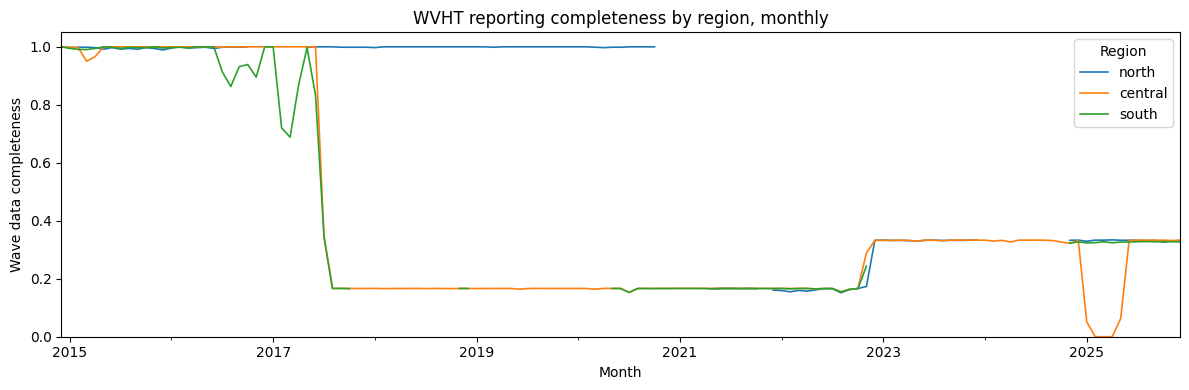

In [37]:
# ============================================================
# Monthly completeness timeline for wave measurements
# ============================================================
# Visualize whether wave-data gaps are concentrated in specific time periods
# (indicating outages) or spread uniformly (indicating chronic sensor issues).

monthly_wave_completeness = (
    cleaned_stdmet
    .assign(has_wave=cleaned_stdmet['WVHT'].notna())
    .groupby(['region', pd.Grouper(freq='ME')])['has_wave']
    .mean()
    .unstack('region')
    .reindex(columns=['north', 'central', 'south'])
)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_wave_completeness.plot(ax=ax, linewidth=1.2)
ax.set_ylabel('Wave data completeness')
ax.set_xlabel('Month')
ax.set_title('WVHT reporting completeness by region, monthly')
ax.set_ylim(0, 1.05)
ax.legend(title='Region')
plt.tight_layout()
plt.show()

### Sampling Daily Averages to Eliminate Collection Frequency Bias
From the above completeness analysis, we found that measurement frequencies of wave data were altered twice, since wave metrics dropped from 100% to 16% and rose to 33%, remaining flat for years each. 

The best fix will be to transform the table, taking the average measurements over six hour periods and combining them into a single row for that period. This will allow us to avoid significantly over-weighting data from the highest-frequency measurement days.

Before doing this, we'll also want to eliminate any entries that were duplicates for a given moment.

In [38]:
# ============================================================
# Resample to 6-hourly to eliminate cadence effects across regions and eras
# ============================================================

# Remove duplicate entries for a given time
cleaned_stdmet = cleaned_stdmet[~cleaned_stdmet.index.duplicated(keep='first')]

cleaned_stdmet = (
    cleaned_stdmet
    .groupby('region')
    .resample('6h')
    .agg({'WVHT': 'mean', 'DPD': 'mean', 'MWD': 'mean',
          'WSPD': 'mean', 'WDIR': 'mean', 'WTMP': 'mean'})
)

# Examine the altered dataframe
cleaned_stdmet.info()

<class 'pandas.DataFrame'>
MultiIndex: 48217 entries, ('central', Timestamp('2015-01-01 00:00:00')) to ('south', Timestamp('2025-12-31 18:00:00'))
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WVHT    35682 non-null  float64
 1   DPD     35573 non-null  float64
 2   MWD     35287 non-null  float64
 3   WSPD    35388 non-null  float64
 4   WDIR    34080 non-null  float64
 5   WTMP    33436 non-null  float64
dtypes: float64(6)
memory usage: 2.5+ MB


### Defining and Eliminating Physically Implausible Data
According to the Oregon Department of Geology and Mineral Industries, the highest significant wave recorded by a buoy was 47.6 feet high in 2007. However, there's no guarantee that WVHT--or any of our other data--is free of record-surpassing, physically implausible, or even logically impossible data. Here, we define reasonable ranges for our data, and convert any data outside those ranges into Not-a-Number for statistical exclusion.

| Column | Range | Justification |
| ------ | ------ | --------------------- |
| WVHT | [0,15] meters | Anything higher than 15 meters would be an unknown record-breaking event, and we will not count it. |
| DPD | [2,30] seconds | Under 2s would be entirely wind chop; over 30 seconds is already exceptionally long. |
| WDIR, MWD | [0,360) degrees | This is a logical constraint. |
| WTMP | [5, 25] celsius | Record-breaking data was unavailable, but temperatures almost never stray outside [6, 21]. |
| WSPD | [0, 50] meters/sec | While gusts can exceed 50 m/s, averages at this level (= level 3 hurricane) are unheard of in Oregon. |

In [39]:
# ============================================================
# Apply plausibility filter: replace out-of-range values with NaN
# ============================================================

# Define plausibility ranges
PLAUSIBLE_RANGES = {
    # Wave variables
    'WVHT': (0.0, 15.0),
    'DPD': (2.0, 30.0),
    'MWD': (0.0, 360.0),
    # Wind variables
    'WDIR': (0.0, 360.0),
    'WSPD': (0.0, 50.0),
    # Ocean temperature
    'WTMP': (5.0, 25.0)
}

# Count invalid values per column before replacing them, then report.
invalid_counts = {}
for col, (lo, hi) in PLAUSIBLE_RANGES.items():
    if col not in stdmet.columns:
        continue
    mask = stdmet[col].notna() & ((stdmet[col] < lo) | (stdmet[col] > hi))
    invalid_counts[col] = int(mask.sum())
    stdmet.loc[mask, col] = np.nan

# Examine the report on removed data. If significant amounts of data were
# cleaned, re-evaluate the ranges. There may not be any.
invalid_report = (
    pd.Series(invalid_counts, name='values_outside_plausible_range')
    .to_frame()
    .assign(pct_of_nonnull=lambda df: (
        df['values_outside_plausible_range']
        / stdmet[list(invalid_counts)].notna().sum()
        * 100
    ).round(3))
)
invalid_report

,values_outside_plausible_range,pct_of_nonnull
WVHT,0,0.0
DPD,0,0.0
MWD,0,0.0
WDIR,0,0.0
WSPD,0,0.0
WTMP,0,0.0


### Data Cleaning Summary
You may notice that we do not impute missing values, or drop rows with any null data. In our case, both would be a mistake. We don't know whether any remaining missing values are due to random sensor issues, or in fact due to conditions we don't want to bias against. With over 33,000 full rows to analyze, we have plenty of data to perform a rigorous analysis and compare regional differences in surfing conditions.
Thankfully, many of the typical data cleaning issues associated with string data are not present with our numerical data, and may safely be skipped!

### Adding Geographic Data
In the next section, it turns out we will need the latitude and longitude of the collected data for some nice geographic visualizations. Since it has nothing to do with data cleaning, we can safely do it anywhere up to this point. Let's do it now.

In [40]:
# ============================================================
# Attach buoy coordinates to each row via the region to station map
# ============================================================
# Map region back to station, then station to lat/lon. This keeps the
# location metadata as columns we can pass directly to plotly.
station_by_region = {region: station for region, station in BUOYS.items()}

cleaned_stdmet = cleaned_stdmet.reset_index()  # bring 'region' out of index if needed
cleaned_stdmet['station'] = cleaned_stdmet['region'].map(station_by_region)
cleaned_stdmet['lat'] = cleaned_stdmet['station'].map(
    lambda s: BUOY_LOCATIONS[s]['lat']
)
cleaned_stdmet['lon'] = cleaned_stdmet['station'].map(
    lambda s: BUOY_LOCATIONS[s]['lon']
)

# Exploratory Data Analysis (Phase 2)

As we move forward into our analysis of surfing conditions, it will be helpful to get a sense of certain characteristics of our data. For example:   
+ How regionally consistent is our data? Maybe the offshore data isn't going to tell us anything about regional differences. If so, it would be good to know now.  
+ How consistent over time is our data? This shapes whether a predictive model will be useful.  
+ Finally, and perhaps most important, what relationships exist between our data values? These relationships will (hopefully) be consistent across data sets, but if you're using a different selection of data than I did, it will be important for you to verify these relationships before performing the same detailed analysis that I did.   

In this section, we'll begin to explore the characteristics of our chosen, cleaned dataset with some helpful visualizations.

## Regional & Temporal Consistency Across All Data Values
Addressing all of our exploratory data analysis questions simultaneously, we can create a beautiful geographic visualization of some of our key data metrics over time using Plotly, a powerful library for interactive visualizations. In the below code, we will create a 2 by 2 grid of geographic bubble maps with time series functionality. Between these four maps, we'll see all seven of our remaining metrics plotted beautifully over time in weekly frames.

Note: The following code was built with the assistance of an AI tool. This is a beefy animation, and it may take your device several seconds to calculate and render.

In [41]:
# ============================================================
# Animated 2x2 map grid with NaN-aware rendering
# ============================================================

SUBPLOTS = [
    {'metric': 'WVHT', 'label': 'Wave Height',     'unit': 'm',
     'direction': 'MWD',  'color': '#1f77b4', 'map_id': 'map'},
    {'metric': 'DPD',  'label': 'Wave Period',     'unit': 's',
     'direction': 'MWD',  'color': '#9467bd', 'map_id': 'map2'},
    {'metric': 'WSPD', 'label': 'Wind Speed',      'unit': 'm/s',
     'direction': 'WDIR', 'color': '#2ca02c', 'map_id': 'map3'},
    {'metric': 'WTMP', 'label': 'Water Temperature', 'unit': '°C',
     'direction': None,   'color': '#d62728', 'map_id': 'map4'},
]

# Explicit domains for the 2x2 grid with gaps between panels.
DOMAINS = {
    'map':  dict(x=[0.00, 0.49], y=[0.54, 1.00]),
    'map2': dict(x=[0.51, 1.00], y=[0.54, 1.00]),
    'map3': dict(x=[0.00, 0.49], y=[0.00, 0.46]),
    'map4': dict(x=[0.51, 1.00], y=[0.00, 0.46]),
}
TITLE_POS = {
    'map':  {'x': 0.245, 'y': 1.005},
    'map2': {'x': 0.755, 'y': 1.005},
    'map3': {'x': 0.245, 'y': 0.465},
    'map4': {'x': 0.755, 'y': 0.465},
}

# ------------------------------------------------------------
# Aggregation: period means with circular mean for directions
# ------------------------------------------------------------
def circular_mean(degrees):
    s = degrees.dropna()
    if len(s) == 0:
        return np.nan
    rad = np.radians(s)
    return np.degrees(np.arctan2(np.sin(rad).mean(),
                                 np.cos(rad).mean())) % 360

df = cleaned_stdmet.reset_index() if 'time' not in cleaned_stdmet.columns \
    else cleaned_stdmet.copy()
# Bin to weekly periods
df['period'] = df['time'].dt.to_period('W').dt.start_time

agg_funcs = {col: 'mean' for col in ['WVHT', 'DPD', 'WSPD', 'WTMP']}
agg_funcs.update({col: circular_mean for col in ['MWD', 'WDIR']})

agg = (
    df.groupby(['period', 'region', 'station', 'lat', 'lon'])
      .agg(agg_funcs)
      .reset_index()
      .sort_values('period')
)
agg['period_str'] = agg['period'].dt.strftime('%Y-%m-%d')

# ------------------------------------------------------------
# Bubble sizing — per metric
# ------------------------------------------------------------
SIZE_MIN, SIZE_MAX = 10, 50
metric_ranges = {
    s['metric']: (agg[s['metric']].min(), agg[s['metric']].max())
    for s in SUBPLOTS
}

def scale_size(value, vmin, vmax):
    if pd.isna(value) or vmax == vmin:
        return SIZE_MIN
    return SIZE_MIN + (value - vmin) / (vmax - vmin) * (SIZE_MAX - SIZE_MIN)

# Arrows
ARROW_LENGTH_DEG = 0.50
def arrow_endpoint(lat, lon, direction_deg):
    if pd.isna(direction_deg):
        return None, None
    theta = np.radians((direction_deg + 180) % 360)
    return (lat + ARROW_LENGTH_DEG * np.cos(theta),
            lon + ARROW_LENGTH_DEG * np.sin(theta))

# ------------------------------------------------------------
# Build frames. Three traces per subplot (bubble / arrow / no-data),
# in the same order across all frames so animation works.
# ------------------------------------------------------------
periods_sorted = agg['period_str'].unique()
frames = []

for period_str in periods_sorted:
    pdf = agg[agg['period_str'] == period_str]
    frame_data = []

    for sp in SUBPLOTS:
        metric, dir_col = sp['metric'], sp['direction']
        vmin, vmax = metric_ranges[metric]

        has_mask = pdf[metric].notna()
        has = pdf[has_mask]
        missing = pdf[~has_mask]

        # 1. Bubble trace (data present)
        frame_data.append(go.Scattermap(
            lat=list(has['lat']),
            lon=list(has['lon']),
            mode='markers',
            marker=dict(
                size=[scale_size(v, vmin, vmax) for v in has[metric]],
                color=sp['color'],
                opacity=0.85,
            ),
            text=[
                (f"<b>{r['region'].title()} Coast</b><br>"
                 f"Station {r['station']}<br>"
                 f"{sp['label']}: {r[metric]:.2f} {sp['unit']}"
                 + (f"<br>Direction: {r[dir_col]:.0f}°"
                    if dir_col and pd.notna(r[dir_col]) else ""))
                for _, r in has.iterrows()
            ],
            hoverinfo='text',
            subplot=sp['map_id'],
            showlegend=False,
        ))

        # 2. Arrow trace
        arrow_lats, arrow_lons = [], []
        if dir_col is not None:
            for _, row in has.iterrows():
                end_lat, end_lon = arrow_endpoint(
                    row['lat'], row['lon'], row[dir_col]
                )
                if end_lat is not None:
                    arrow_lats.extend([row['lat'], end_lat, None])
                    arrow_lons.extend([row['lon'], end_lon, None])
        frame_data.append(go.Scattermap(
            lat=arrow_lats, lon=arrow_lons,
            mode='lines',
            line=dict(width=3, color='rgba(50, 50, 50, 0.75)'),
            hoverinfo='skip',
            subplot=sp['map_id'],
            showlegend=False,
        ))

        # 3. No-data marker (always present at buoy location)
        frame_data.append(go.Scattermap(
            lat=list(missing['lat']),
            lon=list(missing['lon']),
            mode='markers',
            marker=dict(
                size=11,
                color='rgba(0,0,0,0)',  # transparent fill
            ),
            text=[
                f"<b>{r['region'].title()} Coast</b><br>"
                f"Station {r['station']}<br>"
                f"<i>No {sp['label'].lower()} data this period</i>"
                for _, r in missing.iterrows()
            ],
            hoverinfo='text',
            subplot=sp['map_id'],
            showlegend=False,
        ))

    frames.append(go.Frame(data=frame_data, name=period_str))

# Initial figure
fig = go.Figure(data=list(frames[0].data), frames=frames)

for fr in frames:
    for trace in fr.data:
        if trace.mode == 'markers' and trace.marker.color == 'rgba(0,0,0,0)':
            trace.marker.color = 'rgba(170, 170, 170, 0.45)'
for trace in fig.data:
    if trace.mode == 'markers' and trace.marker.color == 'rgba(0,0,0,0)':
        trace.marker.color = 'rgba(170, 170, 170, 0.45)'

# ------------------------------------------------------------
# Layout — explicit domains, no make_subplots
# ------------------------------------------------------------
def map_cfg(map_id):
    return dict(
        style='carto-positron',
        center=dict(lat=44.3, lon=-125.2),
        zoom=5.4,
        domain=DOMAINS[map_id],
    )

panel_titles = [
    dict(
        text=f"<b>{sp['label']}</b> "
             f"<span style='color:#888;font-size:11px'>({sp['unit']})</span>",
        x=TITLE_POS[sp['map_id']]['x'],
        y=TITLE_POS[sp['map_id']]['y'],
        xref='paper', yref='paper',
        showarrow=False,
        font=dict(size=15, color='#222', family='Arial, sans-serif'),
        xanchor='center', yanchor='bottom',
    )
    for sp in SUBPLOTS
]

n = len(periods_sorted)
label_every = max(1, n // 20)  # ~20 labeled ticks across the slider

fig.update_layout(
    autosize=False,
    width=1300,
    height=1050,
    paper_bgcolor='#fafafa',
    margin=dict(l=30, r=30, t=110, b=110),
    title=dict(
        text="<b>Oregon Offshore Buoy Conditions Over Time</b><br>"
             "<span style='font-size:12px;color:#666'>"
             "Bubble size encodes magnitude · Arrow shows direction "
             "waves/wind are heading · Gray = no data this period</span>",
        x=0.5, xanchor='center', y=0.985,
        font=dict(size=18, family='Arial, sans-serif'),
    ),
    annotations=panel_titles,
    map=map_cfg('map'),
    map2=map_cfg('map2'),
    map3=map_cfg('map3'),
    map4=map_cfg('map4'),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        x=0.05, y=-0.04, xanchor='left', yanchor='top',
        bgcolor='#fff', bordercolor='#ccc', borderwidth=1,
        font=dict(size=12),
        buttons=[
            dict(label='▶  Play', method='animate',
                 args=[None, {'frame': {'duration': 150, 'redraw': True},
                              'fromcurrent': True,
                              'transition': {'duration': 80,
                                             'easing': 'cubic-in-out'}}]),
            dict(label='❚❚  Pause', method='animate',
                 args=[[None], {'frame': {'duration': 0, 'redraw': False},
                                'mode': 'immediate'}]),
        ],
    )],
    sliders=[dict(
        active=0,
        currentvalue={'prefix': 'Week of: ',
                      'font': {'size': 13, 'color': '#444'}},
        x=0.18, len=0.78, y=-0.04,
        bgcolor='#e8e8e8', activebgcolor='#666',
        steps=[
            dict(method='animate',
                 args=[[p], {'frame': {'duration': 150, 'redraw': True},
                             'mode': 'immediate',
                             'transition': {'duration': 80}}],
                 label=p if i % label_every == 0 else '')
            for i, p in enumerate(periods_sorted)
        ],
    )],
)

fig.show()

## Correlation Maps of our Data

As we can see from the above time-series visualization, it may appear that the regions are often rather in sync. While the above visualization is useful for getting a sense of the trends in the data, we can more rigorously analyze the relationships between variables--and between regions--using heat maps.

In the following code, we will create one large heatmap just for analyzing how each of our variables relates to each other (i.e., how correlated are wind speed and dominant wave period?), as well as a set of small heatmaps demonstrating the inter-regional correlation of each variable (such as how much dominant wave period in the respective regions are intercorrelated). However, we will need to leave out the directional data, since correlation isn't meaningful without decomposing the degrees into trigonometric components. 

In [42]:
# ============================================================
# Correlation Analysis
# ============================================================
# Two complementary views:
#   1. Variable × Variable correlation (pooled across regions)
#   2. Region × Region correlation, one panel per variable

# Get a clean working copy with 'time' as a column
df = cleaned_stdmet.reset_index() if 'time' not in cleaned_stdmet.columns \
    else cleaned_stdmet.copy()

SCALAR_VARS = ['WVHT', 'DPD', 'WSPD', 'WTMP']
VAR_LABELS = {
    'WVHT': 'Wave Height',
    'DPD':  'Wave Period',
    'WSPD': 'Wind Speed',
    'WTMP': 'Water Temp',
}
REGIONS = ['north', 'central', 'south']

# ============================================================
# Heatmap 1: Variable × Variable correlation (all regions pooled)
# ============================================================
corr_vars = df[SCALAR_VARS].corr()
# Apply readable labels
corr_vars.index = [VAR_LABELS[v] for v in corr_vars.index]
corr_vars.columns = [VAR_LABELS[v] for v in corr_vars.columns]

fig1 = go.Figure(data=go.Heatmap(
    z=corr_vars.values,
    x=corr_vars.columns,
    y=corr_vars.index,
    colorscale='RdBu',
    zmid=0, zmin=-1, zmax=1,
    text=corr_vars.round(2).values,
    texttemplate='%{text}',
    textfont=dict(size=14, color='#222'),
    hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>r = %{z:.3f}<extra></extra>',
    colorbar=dict(title='Pearson r', thickness=14, len=0.8),
))
fig1.update_layout(
    title=dict(
        text='<b>Variable Correlations</b><br>'
             "<span style='font-size:12px;color:#666'>"
             "Pooled across all three regions · 6-hour aggregated data"
             "</span>",
        x=0.5, xanchor='center',
    ),
    width=650, height=550,
    paper_bgcolor='#fafafa',
    margin=dict(l=80, r=80, t=100, b=60),
    xaxis=dict(side='bottom', tickangle=0),
    yaxis=dict(autorange='reversed'),  # diagonal goes top-left to bottom-right
)
fig1.show()


# ============================================================
# Heatmap 2: Region × Region correlation, one panel per variable
# ============================================================
# Pivot to wide format: rows = timestamp, columns = region, one frame per variable.
# Then compute the 3×3 region correlation matrix per variable.

region_corrs = {}
for var in SCALAR_VARS:
    wide = df.pivot_table(index='time', columns='region', values=var,
                          aggfunc='mean')
    # Reorder columns for consistent display
    wide = wide.reindex(columns=REGIONS)
    region_corrs[var] = wide.corr()

# Build a 2×2 subplot grid of 3×3 heatmaps
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[VAR_LABELS[v] for v in SCALAR_VARS],
    horizontal_spacing=0.18,
    vertical_spacing=0.18,
)

positions = [(1, 1), (1, 2), (2, 1), (2, 2)]
for (r, c), var in zip(positions, SCALAR_VARS):
    cm = region_corrs[var]
    fig2.add_trace(
        go.Heatmap(
            z=cm.values,
            x=[reg.title() for reg in cm.columns],
            y=[reg.title() for reg in cm.index],
            colorscale='RdBu',
            zmid=0, zmin=-1, zmax=1,
            text=cm.round(2).values,
            texttemplate='%{text}',
            textfont=dict(size=13, color='#222'),
            hovertemplate=(f'<b>{VAR_LABELS[var]}</b><br>'
                           '%{y} vs %{x}<br>r = %{z:.3f}<extra></extra>'),
            showscale=(r == 1 and c == 2),  # only one shared colorbar
            colorbar=dict(title='Pearson r', thickness=12, len=0.7,
                          x=1.05, y=0.5),
        ),
        row=r, col=c,
    )
    # Reverse y-axis on each subplot so the diagonal reads top-left to 
    # bottom-right
    fig2.update_yaxes(autorange='reversed', row=r, col=c)

fig2.update_layout(
    title=dict(
        text='<b>Regional Synchronization by Variable</b><br>'
             "<span style='font-size:12px;color:#666'>"
             "How closely do the three regions' measurements move together?"
             "</span>",
        x=0.5, xanchor='center',
    ),
    width=900, height=750,
    paper_bgcolor='#fafafa',
    margin=dict(l=60, r=120, t=110, b=60),
)
fig2.show()

## Summary Statistics

For our final set of exploratory visualizations, we'll hone in on our most important data, that which most significantly influences surfing conditions: the wave height and dominant wave periods by region. We will also plot wind speed and water temperature similarly, since they appear to be less regionally correlated and the distributions may differ more. In the following code, we'll create histograms for the distribution of each variable in each region. We will overlay these histograms with three helpful additional details:
+ Mean line (solid)
+ Median line (dotted)
+ KDE curve (used to show the estimated probability distribution as a smooth curve)

In [43]:
# ============================================================
# Distribution panels: WVHT and DPD by region
# ============================================================
# 2×3 grid: top row = wave height by region, bottom = wave period by region.
# Each panel shows histogram + KDE curve + mean/median markers.

df = cleaned_stdmet.reset_index() if 'time' not in cleaned_stdmet.columns \
    else cleaned_stdmet.copy()

REGIONS = ['north', 'central', 'south']
REGION_COLORS = {
    'north':   '#2E86AB',  # blue
    'central': '#A23B72',  # magenta
    'south':   '#F18F01',  # orange
}

VARS = [
    {'col': 'WVHT', 'label': 'Wave Height', 'unit': 'm',  'row': 1},
    {'col': 'DPD',  'label': 'Wave Period', 'unit': 's',  'row': 2},
    {'col': 'WSPD', 'label': 'Wind Speed',       'unit': 'm/s', 'row': 3},
    {'col': 'WTMP', 'label': 'Water Temperature','unit': '°C',  'row': 4},
]

# Compute global x-ranges per variable so all three regional panels share scale
x_ranges = {
    v['col']: (df[v['col']].quantile(0.001), df[v['col']].quantile(0.999))
    for v in VARS
}

# ------------------------------------------------------------
# Build the figure
# ------------------------------------------------------------
fig = make_subplots(
    rows=4, cols=3,
    subplot_titles=[
        f"{r.title()} Coast" for r in REGIONS
    ] + [
        f"{r.title()} Coast" for r in REGIONS
    ],
    horizontal_spacing=0.06,
    vertical_spacing=0.18,
    shared_yaxes=False,
)

for v in VARS:
    col_name = v['col']
    xmin, xmax = x_ranges[col_name]
    x_grid = np.linspace(xmin, xmax, 300)

    for col_idx, region in enumerate(REGIONS, start=1):
        data = df.loc[df['region'] == region, col_name].dropna()

        if len(data) < 2:
            continue  # skip regions with no data

        color = REGION_COLORS[region]

        # Histogram (probability density, transparent fill)
        fig.add_trace(
            go.Histogram(
                x=data,
                histnorm='probability density',
                marker=dict(color=color, opacity=0.35,
                            line=dict(color=color, width=0.5)),
                nbinsx=40,
                showlegend=False,
                hovertemplate=f'{v["label"]}: %{{x:.2f}} {v["unit"]}<br>'
                              'Density: %{y:.3f}<extra></extra>',
            ),
            row=v['row'], col=col_idx,
        )

        # KDE curve over the histogram
        kde = stats.gaussian_kde(data)
        y_kde = kde(x_grid)
        fig.add_trace(
            go.Scatter(
                x=x_grid, y=y_kde,
                mode='lines',
                line=dict(color=color, width=2.5),
                showlegend=False,
                hovertemplate=f'{v["label"]}: %{{x:.2f}} {v["unit"]}<br>'
                              'Density: %{y:.3f}<extra></extra>',
            ),
            row=v['row'], col=col_idx,
        )

        # Mean and median vertical lines
        mean_val = data.mean()
        median_val = data.median()
        y_max = max(y_kde) * 1.05

        fig.add_trace(
            go.Scatter(
                x=[mean_val, mean_val], y=[0, y_max],
                mode='lines',
                line=dict(color='#222', width=1.5, dash='solid'),
                showlegend=False,
                hovertemplate=f'Mean: {mean_val:.2f} {v["unit"]}<extra></extra>',
            ),
            row=v['row'], col=col_idx,
        )
        fig.add_trace(
            go.Scatter(
                x=[median_val, median_val], y=[0, y_max],
                mode='lines',
                line=dict(color='#222', width=1.5, dash='dot'),
                showlegend=False,
                hovertemplate=f'Median: {median_val:.2f} {v["unit"]}<extra></extra>',
            ),
            row=v['row'], col=col_idx,
        )

        # Annotate sample size in upper-right corner of panel
        fig.add_annotation(
            text=f"n = {len(data):,}<br>"
                 f"μ = {mean_val:.2f} {v['unit']}<br>"
                 f"M = {median_val:.2f} {v['unit']}",
            xref=f"x{(v['row']-1)*3 + col_idx if (v['row']-1)*3 + col_idx > 1 else ''} domain",
            yref=f"y{(v['row']-1)*3 + col_idx if (v['row']-1)*3 + col_idx > 1 else ''} domain",
            x=0.97, y=0.95,
            xanchor='right', yanchor='top',
            showarrow=False,
            font=dict(size=10, color='#444'),
            bgcolor='rgba(255,255,255,0.7)',
            bordercolor='#ccc', borderwidth=1, borderpad=4,
        )

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
# Set consistent x-axis ranges per variable row
for col_idx in range(1, 4):
    for v in VARS:
        fig.update_xaxes(
            range=list(x_ranges[v['col']]),
            title_text=f"{v['label']} ({v['unit']})" if col_idx == 2 else None,
            row=v['row'], col=col_idx,
            gridcolor='#eee',
            zeroline=False,
        )
        fig.update_yaxes(
            title_text='Density' if col_idx == 1 else None,
            row=v['row'], col=col_idx,
            gridcolor='#eee',
            zeroline=False,
        )

fig.update_layout(
    title=dict(
        text="<b>Regional Distributions: Wave Height & Wave Period</b><br>"
             "<span style='font-size:12px;color:#666'>"
             "Histograms with KDE overlay · Solid line = mean · Dotted line = median"
             "</span>",
        x=0.5, xanchor='center',
    ),
    height=1200, width=1200,
    paper_bgcolor='#fafafa',
    plot_bgcolor='white',
    margin=dict(l=70, r=40, t=110, b=60),
    bargap=0.05,
)

fig.show()

## Exploratory Data Analysis Observations

From the above visualizations and statistics, a few things are clear. 

### Regional Correlation
For a start, the north, central, and south regions' wave behavior are **highly correlated**. There was, to some degree, a *nearness-effect*: the north and south are less correlated in wave period than they each are to the central region. Meanwhile, wave height was strongly correlated (~90%) between each region, showing very little regional variation.

Meanwhile, wind speed and water temperature were positively correlated, but less so. The statistical summary visualizations demonstrated an odd bimodal distribution for North Coast water temperature that was not replicated in the central and south regions. The North was also the most consistent in wind speed, while the south had a much wider distribution, with more very-calm days and more very-windy days. 

The most important takeaway here is that the regions do not differ nearly as much as hoped for a strong comparison of surfing conditions. However, it will remain to be seen which region most frequently has days with both good wave height and good dominant wave period. 

### Wave Behavior Distribution
Likely the most important marker of surfing conditions is the dominant wave period (DWP). According to surfertoday.com, DWPs of under eight seconds are generally wind-dominated, choppy, and difficult to catch. 10 seconds or more is where decent surf begins to emerge, with 12-16s DWPs being considered "excellent." As we can see in the DWP distributions, the average record in each region is entirely, well, average, or slightly better. It appears that about half of the observations fall into weak, choppy waves of under 11s DWP, and about half the remainder fall into the good-to-excellent range of 11-16s.

However, there are a few things these statistics don't tell us, that would warrant further exploration. For example, do the dominant wave period and wave height differ between daytime and nighttime observations? Between summer and winter? However, since regional correlation is high, we're unlikely to find that one region secretly gets all its best waves during the summer daytime while the others are wasted on cold winter nights. 

It follows conventional wisdom that wave height would be right-skewed due to extreme wave events, and our data matches that hypothesis, which if nothing else serves to corroborate the quality of our data.

# Phase 3: Question Answering and Conclusion

As we saw in our exploratory data analysis, the north, central, and south regions' most important data characteristics--wave period and height--were strongly corrolated. This *suggests* that the data from these buoys will **not** support any hypothesis of regional supremacy.

In the following section, we will dig deeper into the data. We will attempt to rigorously show that regional differences in surfing conditions are unsupported by the data. Furthermore, we will try to understand an oddity in the dataset, and get a better picture of the buoys' true coverage. To do so, we will analyze three questions.
1. How often did each region experience conditions conducive to *excellent* surfing conditions? Did the Central Coast really get the most?
2. What are the wetsuit requirements of each region like? Is the South Coast meaningfully warmer?
+ *Following the answer of question 2, we raise an additional question:* What's going on with the North Coast Water Temperature binomial distribution? Was there a heat wave confined to the north?
3. Does the data contain evidence of significant storms? If not, there may have been outages, which affects our interpretation of other results.

## Question 1: Excellent Day Frequency

Our first and most important question concerns the frequency of excellent surfing days. We have seen that wave height and dominant period, as well as water temperature and wind speed, are strongly correlated between regions. However, this alone does not tell us that "good surfing days" are strongly correlated between regions.

First, we will need to define what makes for an excellent day at the Oregon Coast. This will concern the intersection of optimal ranges of multiple data points.
Here, we will give a generous range for ideal temperature, since almost all temperatures are bravable with the correct equipment, and our second question concerns comfort more specifically. We set 50 degrees as the lower limit, since below that, the equipment required to prevent hypothermia is cumbersome, uncomfortable, and expensive.

According to surfer discussions online, the following are optimal ranges for surfing:
1. Wave Height: 1-2 meters.
2. Dominant Wave Period: 12-16 seconds.
3. Water Temperature: 10+ degrees celsius. 
4. Wind speed: 0-9 meters per second.

Conventional wisdom holds that the central coast will have the "most" days in the intersection of these ranges. Meanwhile, our exploratory data analysis would indicate no meaningful difference. Let's find out!

While we're at it, it will be easy to perform a similar analysis to count a few other types of days. Let's also define:

**Good Days**: with more permissive ranges than we considered excellent, we'll see if this flattens the curve.
1. Wave Height: 0.75-2.25 meters.
2. Dominant Wave Period: 10-18 seconds.
3. Water temperature and wind speed unchanged.

In [86]:
"""
Phase 3 Question 1: Excellent Condition Counts
"""
ideal_ranges = {
    'WVHT': (1.0, 2.0),
    'DPD': (12.0, 16.0),
    'WTMP': (10.0, 100.0),
    'WSPD': (0.0, 9.0),
}
good_ranges = {
    'WVHT': (0.75, 2.25),
    'DPD': (10.0, 18.0),
    'WTMP': (10.0, 100.0),
    'WSPD': (0.0, 9.0),
}


excellent_days_df = cleaned_stdmet.copy()

good_days_df = cleaned_stdmet.copy()

#filter by the lows and highs.
for col, (low, high) in ideal_ranges.items():
    excellent_days_df = excellent_days_df[excellent_days_df[col] <= high]
    excellent_days_df = excellent_days_df[excellent_days_df[col] >= low]

for col, (low, high) in good_ranges.items():
    good_days_df = good_days_df[good_days_df[col] <= high]
    good_days_df = good_days_df[good_days_df[col] >= low]


# For each region, display the number of days left after filtering.
print(f"Total recordings for each {cleaned_stdmet['region'].value_counts()}\n")

print(f"Excellent records in each {excellent_days_df['region'].value_counts()}\n")

print(f"Merely good records in each {good_days_df['region'].value_counts()}\n")


Total recordings for each region
north      16073
central    16072
south      16072
Name: count, dtype: int64

Excellent records in each region
central    702
north      691
south      626
Name: count, dtype: int64

Merely good records in each region
central    2476
north      2175
south      1820
Name: count, dtype: int64



### Question 1 Answered: Central Coast Wins, Kind Of?

Despite unpromising initial exploration, it turns out that the data somewhat supports central region supremacy. Filtering against both excellent conditions as well as merely good conditions, the central coast has the strongest frequency of each. By "excellent" conditions, the regions are really tied, but by good conditions, the central coast wins out as the most consistent. **This is a big result!**

## Question 2: A Consolation Prize? Regional Variation in Comfort

After analyzing the frequency of excellent and good days, we turn to the question of comfort. Is there a consolation prize, presumably, for the south region, which ought to be warmer? In Oregon, wetsuits are a basic necessity for surfing. However, comfort can still be ranked on several levels.

Similar to the above question, we will *first* filter to days that were *surfable at all.* For our purposes, these ranges will be:
1. Wave Height: 0.5 meters to 2.5 meters. 
2. Dominant Wave Period: 8.0-20.0 seconds.
3. Water Temperature: 9+ degrees celsius.
4. Wind Speed: 0-11 miles per hour.

Then, we will categorize comfort into six levels by the following:
+ Perfect: WTMP of 70 degrees or more. On such an exceptional day, a wetsuit is not required at all.
+ Very comfortable: WTMP 65-70 degrees. Only a shorty wetsuit needed, if at all.
+ Comfortable: WTMP 60-65 degrees. Many surfers would prefer a full length wetsuit at this range.
+ Somewhat uncomfortable: 55-60 degrees. Almost all surfers will use a full length wetsuit.
+ Uncomfortable: 50-55 degrees. Heavy equipment required to surf.
+ Barely surfable: 45-50 degrees.

Finally, to advance this question beyond what we saw in the exploratory statistics above, we're going to need to filter a little further. 
Something we haven't really considered is the time of day of observations. Let's restrict our observations to daytime as well, including lit time just before dawn. For our purposes, we will simply consider this to be 06:00-19:00 to avoid seasonal variance. 

Note that in the code below, these temperatures were approximated in celsius.


Frequency of daytime observations that were even surfable by region
central    3513
north      3047
south      2548
Name: count, dtype: int64



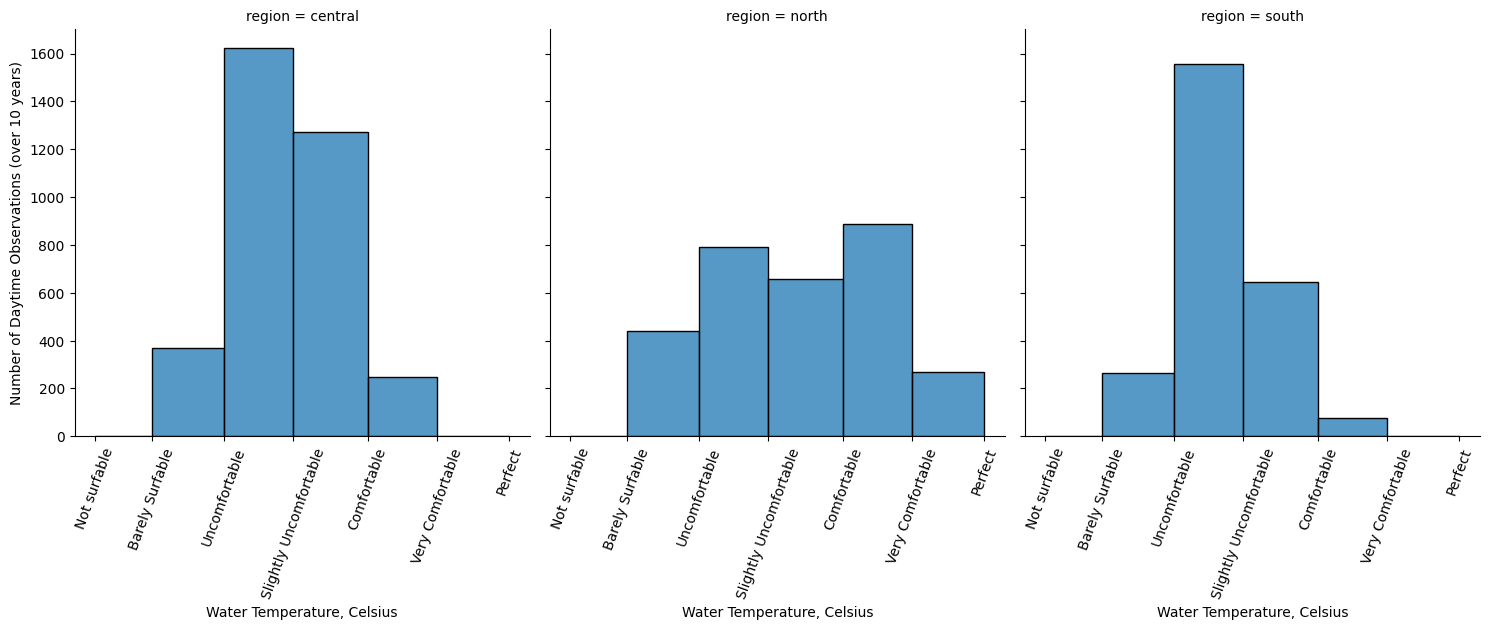

In [87]:
okay_ranges = {
    'WVHT': (0.5, 2.5),
    'DPD': (9.0, 20.0),
    'WTMP': (9.0, 100.0),
    'WSPD': (0.0, 11.0),
}

okay_days_df = cleaned_stdmet.copy()

#Filter to okay conditions
for col, (low, high) in okay_ranges.items():
    okay_days_df = okay_days_df[okay_days_df[col] <= high]
    okay_days_df = okay_days_df[okay_days_df[col] >= low]

#Filter to daytime only
okay_days_df = okay_days_df[okay_days_df['time'].dt.hour <= 19]
okay_days_df = okay_days_df[okay_days_df['time'].dt.hour >= 6]

print(f"Frequency of daytime observations that were even surfable by {okay_days_df['region'].value_counts()}\n")

custom_bin_edges = [
    5.0,
    7.2,
    10,
    12.7,
    15.6,
    18.3,
    21.1,
]

ax = sns.displot(data=okay_days_df, x='WTMP', bins=custom_bin_edges, col='region')
ax.set(
    xlabel="Water Temperature, Celsius",
    ylabel="Number of Daytime Observations (over 10 years)",
    xticks=custom_bin_edges)

ax.set_xticklabels(['Not surfable', 'Barely Surfable', 'Uncomfortable', 'Slightly Uncomfortable', 'Comfortable', 'Very Comfortable', 'Perfect'],
              rotation=70,
            )

plt.show()

### Question 2 Answer: Raising More Questions than It Really Answered

As we can see, even restricted to surfable conditions and only daytime observations, "uncomfortable" is the mode observation for all regions, and the south region does not stand out as being significantly more comfortable than the other two. In fact, it's the north region that has the best spread, straying into comfortable and very comfortable much more often. What's going on here? 

To get a better picture of what's happening, let's take a look at the water temperature over time, separated by region, and see if an anomaly appears for the north.

[Text(0.5, 1.0, 'Water Temperature observations over time by region'),
 Text(0, 0.5, 'Water Temperature, Celsius')]

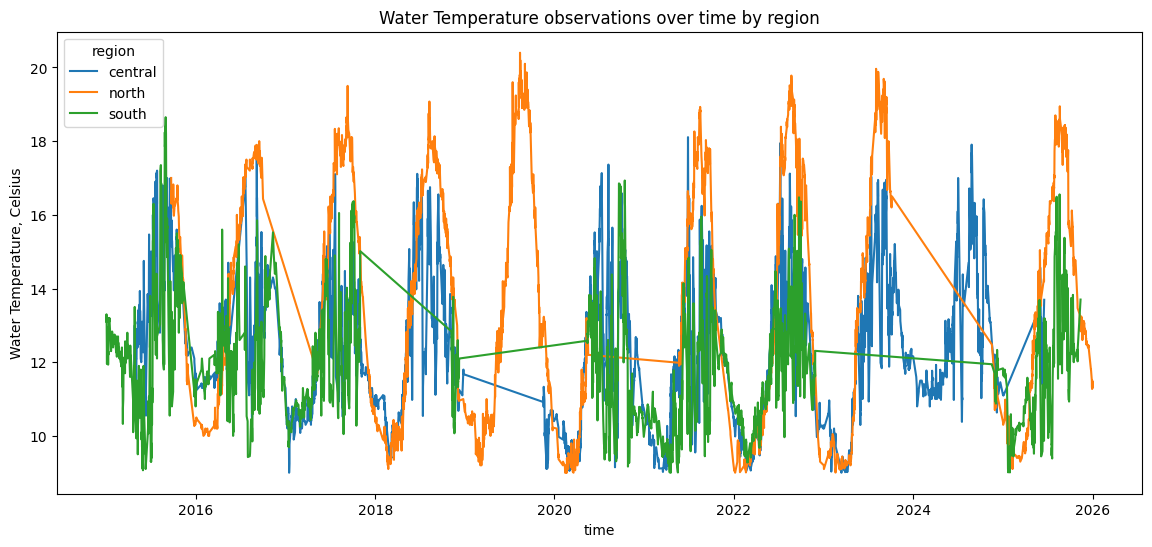

In [88]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=okay_days_df, x='time', y='WTMP', hue='region', ax=ax)
ax.set(
    title="Water Temperature observations over time by region",
    ylabel="Water Temperature, Celsius"
)

### Question 2 Real Answer: The Water Temperature Data is Incomplete, and Kind of Weird

As we can see, it's not so much that the north region experienced a unique heat wave as that the water temperature data is simply incomplete. Originally, we observed the completeness of the *wave data*, and during cleaning, determined that we wanted to keep observations even where temperature was missing, since it was less important for our analysis.

As it turns out, in the summer and autumn of 2019, the north region was quite warm, while we had a prolonged outage on central and south temperature gauges, removing data that may have been similar. We can't rigorously conclude anything definitive about regional temperature comfort. However, it is clear from this chart that when all buoys are functional, the north just appears a bit warmer. **Certainly not an intuitive result!**

## Question 3: Were there storms?

As we can see from the above, outages are definitely a concern with our buoys. We saw during cleaning, while removing extreme outlier values, that there were no physically impossible observations--in that regard, the data is clean. But what about extreme storms? 

So far, we've seen clearly that the central region has the most consistently good surfing conditions, and there's some evidence to suggest the north coast is warmest. One marker we haven't considered is safety--how frequent are extreme storms in each region? Does our data actually contain evidence of any?

In the below code, we'll determine how many extreme observations there were of wind and wave height as markers of dangerous storms.
1. Extreme Wind: 25 mph or higher is too fast for surfing--approximately 11 meters per second.
2. Extreme Wave Height: 4 meters or higher is too dangerous for the vast majority of surfers.

In [93]:

"""
First, we calculate the number of extreme observations actually recorded in each region.
"""
extreme_wind_df = cleaned_stdmet.copy()
extreme_waves_df = cleaned_stdmet.copy()

extreme_wind_df = extreme_wind_df[extreme_wind_df['WSPD'] >= 11.0]
extreme_wind_and_waves_df = extreme_wind_df.copy()

extreme_waves_df = extreme_waves_df[extreme_waves_df['WVHT'] >=4.0]
extreme_wind_and_waves_df = extreme_wind_and_waves_df[extreme_wind_and_waves_df['WVHT'] >= 4.0]

#Print the results
print(f"Stormy Wind Conditions observed in each {extreme_wind_df['region'].value_counts()}")

print(f"Extreme Wave Height observations in each {extreme_waves_df['region'].value_counts()}")

print(f"Occurances of extreme wind and wave height by {extreme_wind_and_waves_df['region'].value_counts()}")

Stormy Wind Conditions observed in each region
south      1265
central    1038
north       790
Name: count, dtype: int64
Extreme Wave Height observations in each region
central    1447
north      1177
south       878
Name: count, dtype: int64
Occurances of extreme wind and wave height by region
central    483
north      384
south      320
Name: count, dtype: int64


### Question 3 Answer: Evidence Of Storms Exists; Survivorship Bias Possible

Here, we can see definitively that there is evidence of stormy conditions successfully observed in each region. Therefore, it isn't clear that buoys are suffering total outages during such extreme events that would otherwise prevent us from analyzing the data fairly.

To more rigorously analyze survivorship bias, one might compute the frequency of outages in each region while another region is experiencing a storm, to gauge whether storms, in fact, cause outages. This data could be used to approximate how extreme conditions need to become for observations to start to go missing. However, doing so would require several steps that were beyond the scope of this phase at this time.

## Phase 3 In Review: More Regional Variance Than Anticipated

During our exploratory data analysis, we suffered the discouraging result that each region seemed very similar, and strongly intercorrelated. As we have seen from a deeper analysis, in fact, there are meaningful regional differences despite the correlation: the central coast achieves good surfing conditions more often than the others, the north is a bit warmer. The south gets the strongest winds, but extreme wind and wave observations are more common in the central coast--suggesting a greater tendency toward bad storms.